### 기존 image-to-image 모델 사용

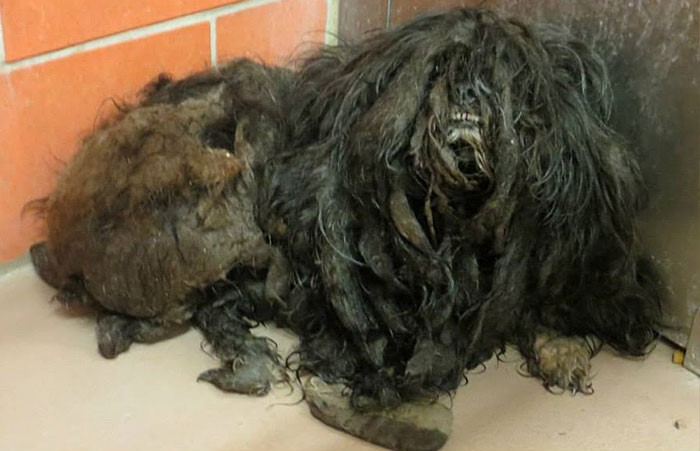

In [18]:
from PIL import Image
image_path = "dog_023_before.jpg"
init_image = Image.open(image_path).convert("RGB")  # RGB 모드로 변환
init_image

100%|██████████| 80/80 [00:07<00:00, 10.89it/s]


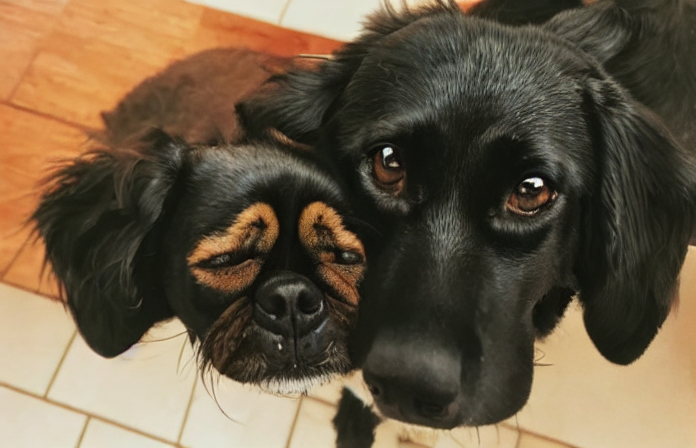

In [20]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import make_image_grid, load_image

pipeline = AutoPipelineForImage2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
)
pipeline.enable_model_cpu_offload()
# remove following line if xFormers is not installed or you have PyTorch 2.0 or higher installed
# pipeline.enable_xformers_memory_efficient_attention()

prompt = "A happy dog, well-groomed dog with bright eyes, clean and fluffy fur, no scars, healthy and well-fed, wagging its tail, standing in a warm and cozy environment, 8k, highly detailed, realistic lighting"
prompt = "A happy dog, healthy and well-fed, standing in a warm and cozy environment, 8k, highly detailed"
prompt = "A happy dog, healthy"
# pass prompt and image to pipeline
image = pipeline(prompt, image=init_image, num_inference_steps=100).images[0]
image

### ControlNet 사용

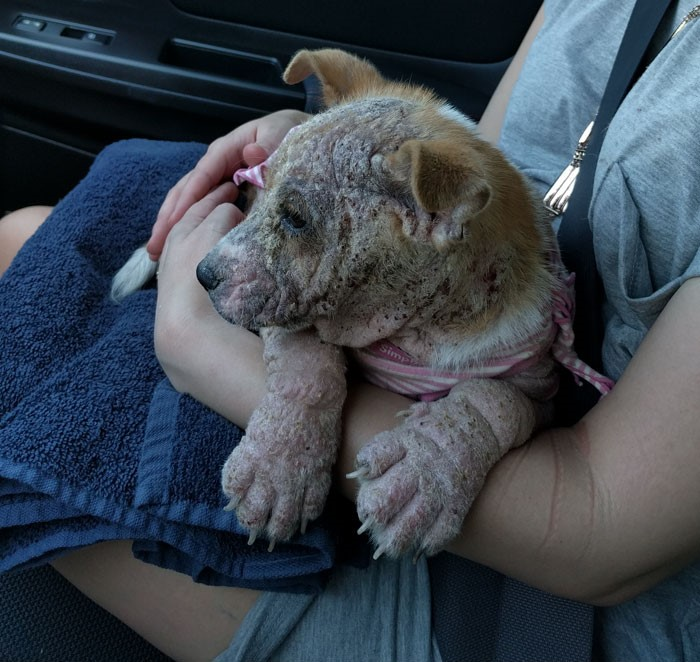

In [31]:
from PIL import Image
image_path = "dog_015_before.jpg"
init_image = Image.open(image_path).convert("RGB")  # RGB 모드로 변환
init_image

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.64it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 50/50 [00:06<00:00,  7.33it/s]


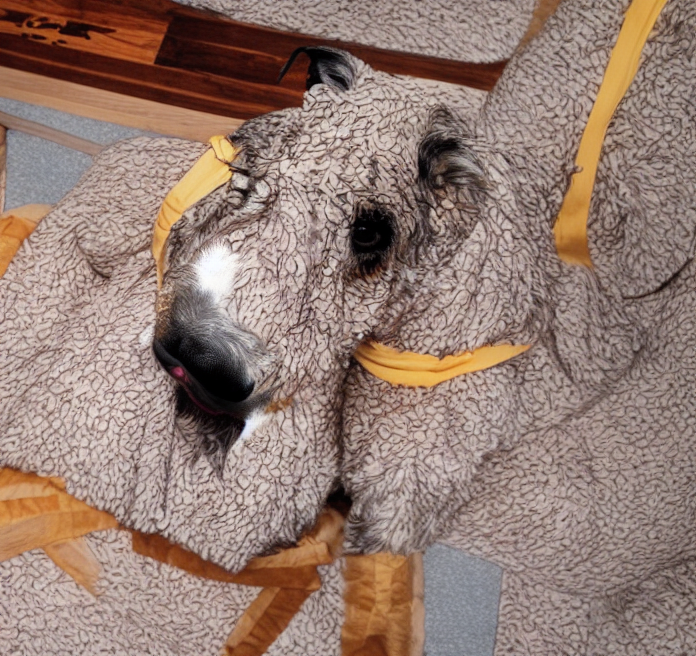

In [33]:
from transformers import pipeline
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from PIL import Image
import numpy as np
import torch
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, safety_checker=None, torch_dtype=torch.float16
)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

prompt = "A happy dog"

pipe.enable_model_cpu_offload()

image = pipe(prompt, init_image, num_inference_steps=50).images[0]
image

### Stable-Diffusion 여러 시도

#### 여러 Seed model

In [16]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import make_image_grid

# Load Image-to-Image Pipeline
pipeline = AutoPipelineForImage2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", 
    torch_dtype=torch.float16, 
    variant="fp16", 
    use_safetensors=True
)
pipeline.enable_model_cpu_offload()

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.72it/s]


In [17]:
from PIL import Image
image_path = "dog_013_before.jpg"
init_image = Image.open(image_path).convert("RGB")  # RGB 모드로 변환

100%|██████████| 16/16 [00:01<00:00,  8.53it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


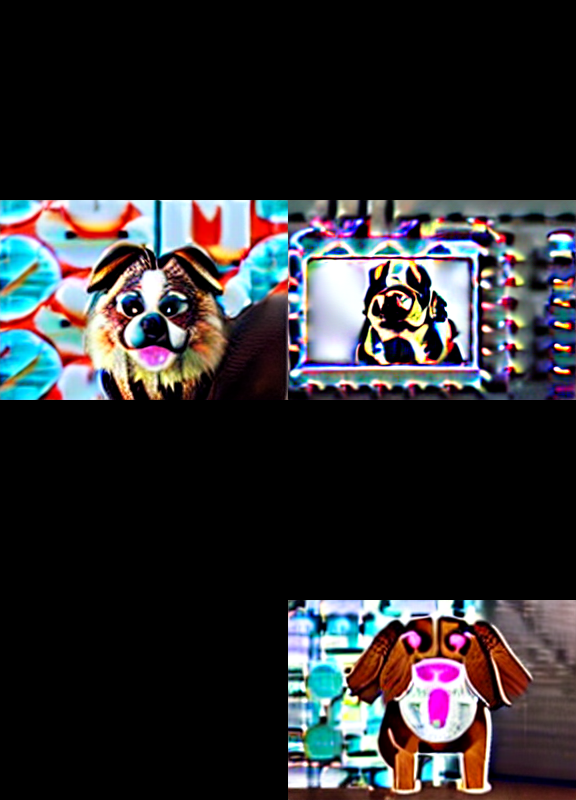

In [15]:
# Define function to generate inputs
def get_inputs(prompt, init_image, batch_size=1, num_inference_steps=20):
    generator = [torch.Generator("cuda").manual_seed(i) for i in range(batch_size)]
    prompts = batch_size * [prompt]
    
    return {
        "prompt": prompts, 
        "image": [init_image] * batch_size, 
        "generator": generator, 
        "num_inference_steps": num_inference_steps
    }

# Generate images
batch_size = 8
prompt = "A happy dog, well-groomed dog with bright eyes, clean and fluffy fur, no scars, healthy and well-fed, wagging its tail, standing in a warm and cozy environment, 8k, highly detailed, realistic lighting"
inputs = get_inputs(prompt, init_image, batch_size=batch_size)
images = pipeline(**inputs).images

# Display images in a 2x2 grid
make_image_grid(images, rows=4, cols=2)

#### Prompt 조정
- prompt_embed 활용

In [31]:
import torch
from compel import Compel
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import make_image_grid, load_image

# Load Image-to-Image Pipeline
# pipeline = AutoPipelineForImage2Image.from_pretrained(
#     "stable-diffusion-v1-5/stable-diffusion-v1-5", 
#     torch_dtype=torch.float16, 
#     variant="fp16", 
#     use_safetensors=True
# )
# pipeline.enable_model_cpu_offload()

In [32]:
from PIL import Image
image_path = "dog_023_before.jpg"
init_image = Image.open(image_path).convert("RGB")  # RGB 모드로 변환

In [33]:
# !pip install compel

In [35]:
# Load an initial image
compel = Compel(tokenizer=pipeline.tokenizer, text_encoder=pipeline.text_encoder)

prompt = "A happy dog++, well-groomed dog with bright eyes, clean and fluffy fur, no scars, healthy and well-fed, wagging its tail, standing in a warm and cozy environment, 8k, highly detailed, realistic lighting"

prompt_embeds = compel(prompt)

image = pipeline(prompt_embeds=prompt_embeds, image=init_image, num_inference_steps=20).images[0]

image.show()

100%|██████████| 16/16 [00:01<00:00, 12.66it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)
Start : This command cannot be run due to the error: The network name cannot be found.
At line:1 char:130
+ ... xt.Encoding]::GetEncoding(65001); Start "\\wsl$\\tmp\tmpqdemm1jm.PNG"
+                                       ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    + CategoryInfo          : InvalidOperation: (:) [Start-Process], InvalidOperationException
    + FullyQualifiedErrorId : InvalidOperationException,Microsoft.PowerShell.Commands.StartProcessCommand
 
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: 